<a href="https://colab.research.google.com/github/shahankit82/ml-assessment-Ankit-Shah/blob/main/Part_a/q3_feature_engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Q3 Feature Engineering and Regression Pipeline

1. Date Feature Engineering

In [3]:
import pandas as pd

# Load dataset
df = pd.read_csv('https://raw.githubusercontent.com/shahankit82/ml-assessment-Ankit-Shah/refs/heads/main/Data/q3_retail_promotions.csv')

# Convert to datetime
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# Extract features
df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek

# Create is_month_end feature
df['is_month_end'] = (df['transaction_date'].dt.day >= 25).astype(int)

# Check results
df.head()

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold,year,month,day_of_week,is_month_end
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224,2022,1,5,0
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348,2022,1,5,0
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249,2022,1,6,0
3,2022-01-02,17,small,urban,free_gift,1,0,7,259,2022,1,6,0
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277,2022,1,0,0


2. Temporal Train-Test Split

In [9]:
# Sort by date
df = df.sort_values('transaction_date')

# Split (80% train, 20% test)
split_index = int(len(df) * 0.8)

train_df = df.iloc[:split_index]
test_df = df.iloc[split_index:]

print(train_df.shape, test_df.shape)

(960, 13) (240, 13)


3. Preprocessing Pipeline

In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Split features and target
X_train = train_df.drop(['items_sold', 'transaction_date'], axis=1)
y_train = train_df['items_sold']

X_test = test_df.drop(['items_sold', 'transaction_date'], axis=1)
y_test = test_df['items_sold']

# Categorical and numerical columns
cat_cols = ['promotion_type', 'location_type', 'store_size']
num_cols = [col for col in X_train.columns if col not in cat_cols]

# Create preprocessing pipeline
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(drop='first'), cat_cols),
    ('num', StandardScaler(), num_cols)
])

4. Model Training and Evaluation

In [6]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Create pipelines
lr_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('model', LinearRegression())
])

rf_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

# Train models
lr_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)

# Predictions
lr_pred = lr_pipeline.predict(X_test)
rf_pred = rf_pipeline.predict(X_test)

# Evaluation function
def evaluate(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    print(f"{model_name} Results:")
    print("RMSE:", rmse)
    print("MAE:", mae)
    print()

# Evaluate both models
evaluate(y_test, lr_pred, "Linear Regression")
evaluate(y_test, rf_pred, "Random Forest")

Linear Regression Results:
RMSE: 27.12145116489062
MAE: 21.052926674588388

Random Forest Results:
RMSE: 31.660007317329118
MAE: 24.87391666666667



5. Parity Plots

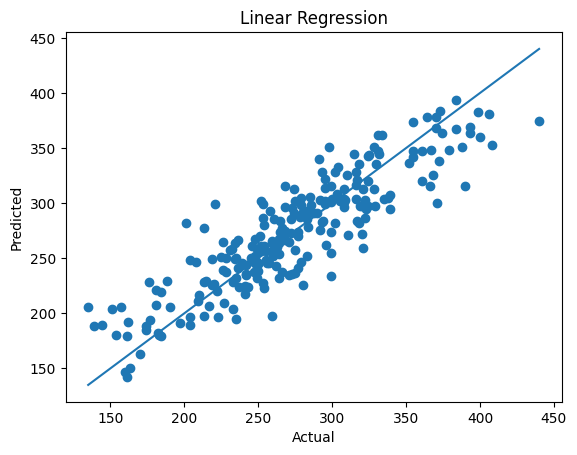

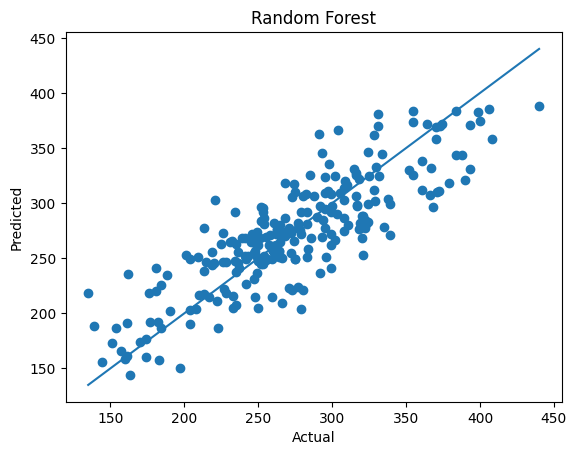

In [7]:
import matplotlib.pyplot as plt

def parity_plot(y_true, y_pred, title):
    plt.scatter(y_true, y_pred)

    # Diagonal line
    plt.plot([y_true.min(), y_true.max()],
             [y_true.min(), y_true.max()])

    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(title)
    plt.show()

# Plot for both models
parity_plot(y_test, lr_pred, "Linear Regression")
parity_plot(y_test, rf_pred, "Random Forest")

6. Feature Importance (Random Forest)

In [8]:
# Extract model
rf_model = rf_pipeline.named_steps['model']

# Get feature names after preprocessing
feature_names = rf_pipeline.named_steps['preprocess'].get_feature_names_out()

# Get importance
importances = rf_model.feature_importances_

# Create dataframe
import pandas as pd
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
})

# Sort
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)

# Top 5 features
feature_importance_df.head(5)

,feature,importance
7,cat__store_size_small,0.183954
10,num__is_festival,0.174477
5,cat__location_type_urban,0.140498
14,num__day_of_week,0.090612
9,num__is_weekend,0.063547
